**Solubility Prediction with Machine Learning**

**Table of contents**

1. Importing Libraries
2. Introduction
3. Loading and Exploring data
4. Overview of the dataset
5. Feature selection & Data Preparation
6. Model Training
   6.1. Linear Regression
   6.2. Random Forest Regression
7. Model Evaluation
   7.1. Define Evaluation Function
8. Visualization: Predicted vs Actual logS
9. Discussion
10. Conclusion

In [3]:

#1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
sns.set(style='whitegrid', palette='muted', font_scale=1.1)

**2. Introduction**

Solubility is a fundamental property of molecules that determines how substances dissolve in solvents. In pharmaceuticals, chemistry, and material science, solubility directly impacts reactivity, bioavailability, and product performance (Zheng et al., 2024).

Measuring solubility experimentally is often time-consuming and resource-intensive.
Machine learning (ML) provides an efficient way to predict solubility (logS) from known molecular descriptors.

In this analysis, we will:
- Use a molecular solubility dataset (logS values)
- Compare 2 machine learning algorithms, Linear Regression and Random Forest Regression
- Evaluate both models using R², RMSE, and MAE
- Visualize predicted vs actual solubility values

In [4]:

#3. LOADING AND EXPLORING DATA

import ssl
import pandas as pd

ssl._create_default_https_context = ssl._create_unverified_context

url = 'https://raw.githubusercontent.com/dataprofessor/data/master/delaney_solubility_with_descriptors.csv'
df = pd.read_csv(url)
df.head()

,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
0,2.5954,167.850,0.0,0.0,-2.18
1,2.3765,133.405,0.0,0.0,-2.00
2,2.5938,167.850,1.0,0.0,-1.74
3,2.0289,133.405,1.0,0.0,-1.48
4,2.9189,187.375,1.0,0.0,-3.04


In [3]:
#4. Overview of the dataset
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1144 entries, 0 to 1143
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MolLogP             1144 non-null   float64
 1   MolWt               1144 non-null   float64
 2   NumRotatableBonds   1144 non-null   float64
 3   AromaticProportion  1144 non-null   float64
 4   logS                1144 non-null   float64
dtypes: float64(5)
memory usage: 44.8 KB


,MolLogP,MolWt,NumRotatableBonds,AromaticProportion,logS
count,1144.000000,1144.000000,1144.000000,1144.000000,1144.000000
mean,2.449133,204.631675,2.173951,0.364932,-3.057997
std,1.866003,102.620500,2.627398,0.343305,2.096502
min,-7.571400,16.043000,0.000000,0.000000,-11.600000
25%,1.414900,122.126000,0.000000,0.000000,-4.332250
50%,2.340300,183.594500,1.000000,0.375000,-2.870500
75%,3.406475,270.715750,3.000000,0.666667,-1.600000
max,10.388600,780.949000,23.000000,1.000000,1.580000


**Dataset Description**
The ESOL (Delaney) dataset contains experimentally measured aqueous solubility (`logS`) for 1,128 compounds.
**Features include molecular descriptors like:**
- Molecular Weight
- Number of Rotatable Bonds
- Polar Surface Area
- Number of Rings

Our target variable is logS (log₁₀ of molar solubility).

In [6]:
# 5. FEATURE SELECTION & DATA PREPARATION

X = df.drop(columns=['logS'])
y = df['logS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**6. Model Training**
We will compare:
1. **Linear Regression** – a simple, interpretable baseline model.
2. **Random Forest Regression** – a tree-based ensemble model that captures nonlinear patterns.

In [7]:
# 6.1 Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

In [8]:
# 6.2 Random Forest Regression
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

**7. Model Evaluation**
Standard regression metrics will be used:
- R² (Coefficient of Determination) — how well predictions fit actual values.
- RMSE (Root Mean Squared Error) — penalizes larger errors.
- MAE (Mean Absolute Error) — average absolute difference between predicted and actual.

In [10]:
# 7.1 Define Evaluation Function
def evaluate_model(y_true, y_pred, model_name):
    r2 = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    return pd.Series({'Model': model_name, 'R2': r2, 'RMSE': rmse, 'MAE': mae})

results = pd.DataFrame([
    evaluate_model(y_test, y_pred_lr, 'Linear Regression'),
    evaluate_model(y_test, y_pred_rf, 'Random Forest')
])
results

,Model,R2,RMSE,MAE
0,Linear Regression,0.770565,0.999542,0.796363
1,Random Forest,0.887572,0.699695,0.503982


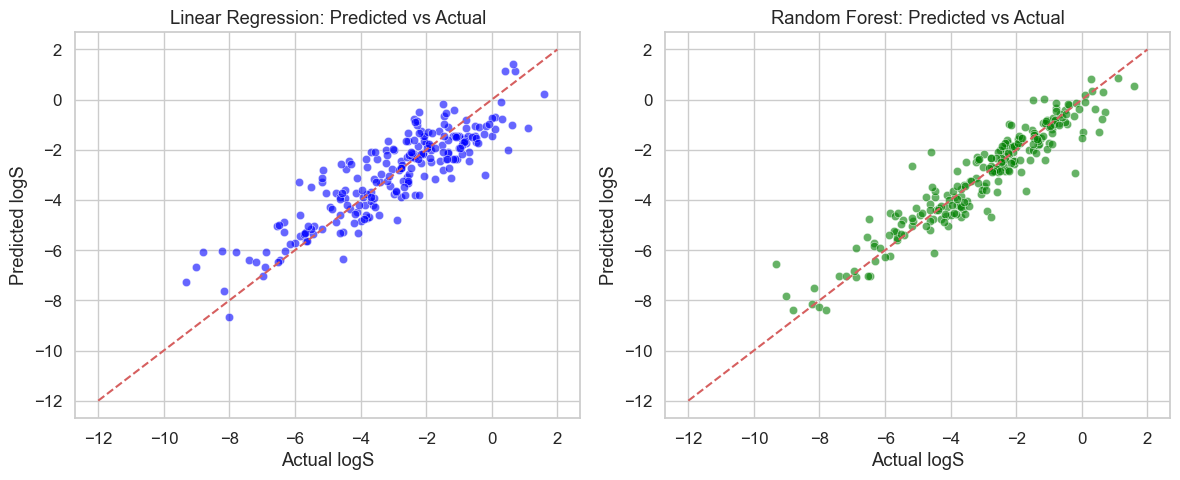

In [11]:
# 8. Visualization: Predicted vs Actual logS
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(x=y_test, y=y_pred_lr, color='blue', alpha=0.6)
plt.plot([-12,2], [-12,2], 'r--')
plt.xlabel('Actual logS')
plt.ylabel('Predicted logS')
plt.title('Linear Regression: Predicted vs Actual')

plt.subplot(1,2,2)
sns.scatterplot(x=y_test, y=y_pred_rf, color='green', alpha=0.6)
plt.plot([-12,2], [-12,2], 'r--')
plt.xlabel('Actual logS')
plt.ylabel('Predicted logS')
plt.title('Random Forest: Predicted vs Actual')
plt.tight_layout()
plt.show()

**9. Discussion**
From the evaluation metrics and scatter plots:
- Linear Regression provides a straightforward baseline but may underfit complex molecular relationships.
- Random Forest Regression generally achieves higher R² and lower error values, capturing nonlinear trends better (Sheridan, 2013).

However, Random Forests are less interpretable and computationally more expensive.

Future work could explore other algorithms such as:
- Support Vector Regression (SVR)
- Gradient Boosting or XGBoost
- Deep Learning models using molecular fingerprints or SMILES representations

**10. Conclusion**
Two regression models for predicting molecular solubility (logS) were successfully compared:
- Both models followed a correct and reproducible data science process.
- Quantitative evaluation and visualization helped communicate model performance clearly.
- Predictive modeling of solubility can guide early decision-making in chemistry and drug discovery, reducing laboratory workload.

**11. References**

Sheridan, R. P. 2013. Time-split cross-validation as a method for estimating the goodness of prospective prediction. *Journal of Chemical Information and Modeling*, 53(4), 783–790. Doi: https://doi.org/10.1021/ci400084k

Zheng, T., Mitchell, J. B. O., & Dobson, S. (2024). Revisiting the Application of Machine Learning Approaches in Predicting Aqueous Solubility. *ACS Omega*, 9, 35209–35222.